In [1]:
import sys
import os
REPO_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.abspath(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from environment.geometry import Geometry
from environment.vehicle import Vehicle, VehicleParams, AirframeParams
from environment.sensors import (SensorSuite, AcousticSensor, DopplerSensor, RCSSensor, CameraSensor,
                                 AcousticParams, DopplerParams, RCSParams, CameraParams)
from environment.game import Game, AttackerWeights, DefenderWeights

print('My lord, we have completed the ritual of importation.')

My lord, we have completed the ritual of importation.


In [2]:
def check(name, condition, detail =""):
    status = 'Grace of the Omnissiah, the holy data has passed the rite of validation' if condition else 'My lord, the data validation has been failed'
    msg = f'[{status}] {name}'
    if detail:
        msg += f' ({detail})'
    print(msg)
    return condition

## SECTION 1 - Geometry Tests

Test for geometry.py: range, LOS angle, radial velocity, aspect angle, and boresight angle

In [3]:
print('=== Geometry Tests ===')

g = Geometry(z_d = 3000.0, camera_elevation_deg=45.0)

# --- range ---
r = g.range(3000.0, 500.0)
check('range: attacker directly above sensor', abs(r-500.0) < 1e-6, f'expected 500.0, got {r}')

r2 = g.range(0.0, 400.0)
expected_r2 = np.sqrt(3000.0**2 + 400.0**2)
check('range: diagonal (3-4-5 triangle)', abs(r2-expected_r2) < 1e-3, f'expected {expected_r2}, got {r2}')

check('range: always positive',
      all(g.range(z, h)>0 for z in [0, 1000, 3000, 5000] for h in [1, 100, 1000]),
      'checked 12 positions')

# --- LOS angle ---
theta = g.los_angle(3000.0, 500.0)
check('LOS angle: attacker directly above sensor', abs(theta-np.pi/2) < 1e-6, f'expected {np.pi/2}, got {theta}')

theta2 = g.los_angle(0.0, 1.0)
check('LOS angle: far away horizontally = 0',
      theta2 < 0.01,
      f'got {np.degrees(theta2)} degrees')

# --- radial velocity ---
v_r = g.radial_velocity(1000.0, 800.0, 22.0, -0.15)
check('radial velocity: positive when approaching',
      v_r > 0,
      f'got {v_r:.4f} m/s')

check('radial velocity: cannot exceed airspeed',
      v_r <= 22.0 + 1e-6,
      f'v_r={v_r:.4f}, v=22.0')

# --- aspect angle ---
for gamma in [-0.05, -0.2, -0.5, -0.7]:
    psi = g.aspect_angle(1500.0, 500.0, gamma)
    check(f'aspect angle in [0, 180] at gamma={np.degrees(gamma):.1f}',
          0 <= psi <= 180,
          f'got {np.degrees(psi):.2f} degrees')
    
# --- boresight angle ---
t_dist = 500.0
z_along = 3000.0 - t_dist*np.cos(np.radians(45.0))
h_along = t_dist*np.sin(np.radians(45.0))
phi = g.boresight_angle(z_along, h_along)
check('boresight angle: target along camera boresight = 0',
      phi < 0.05,
      f'got {np.degrees(phi):.4f} degrees')

# --- all() returns finite values ---
result = g.all(1500, 600, 22.0, -0.15)
check('all(): all values finite',
      all(np.isfinite(v) for v in result.values()),
      str({k: f"{v:.4f}" for k, v in result.items()}))

=== Geometry Tests ===
[Grace of the Omnissiah, the holy data has passed the rite of validation] range: attacker directly above sensor (expected 500.0, got 500.0)
[Grace of the Omnissiah, the holy data has passed the rite of validation] range: diagonal (3-4-5 triangle) (expected 3026.5491900843112, got 3026.5491900843112)
[Grace of the Omnissiah, the holy data has passed the rite of validation] range: always positive (checked 12 positions)
[Grace of the Omnissiah, the holy data has passed the rite of validation] LOS angle: attacker directly above sensor (expected 1.5707963267948966, got 1.5707963267948966)
[Grace of the Omnissiah, the holy data has passed the rite of validation] LOS angle: far away horizontally = 0 (got 0.019098592463672185 degrees)
[Grace of the Omnissiah, the holy data has passed the rite of validation] radial velocity: positive when approaching (got 21.4181 m/s)
[Grace of the Omnissiah, the holy data has passed the rite of validation] radial velocity: cannot exceed 

True

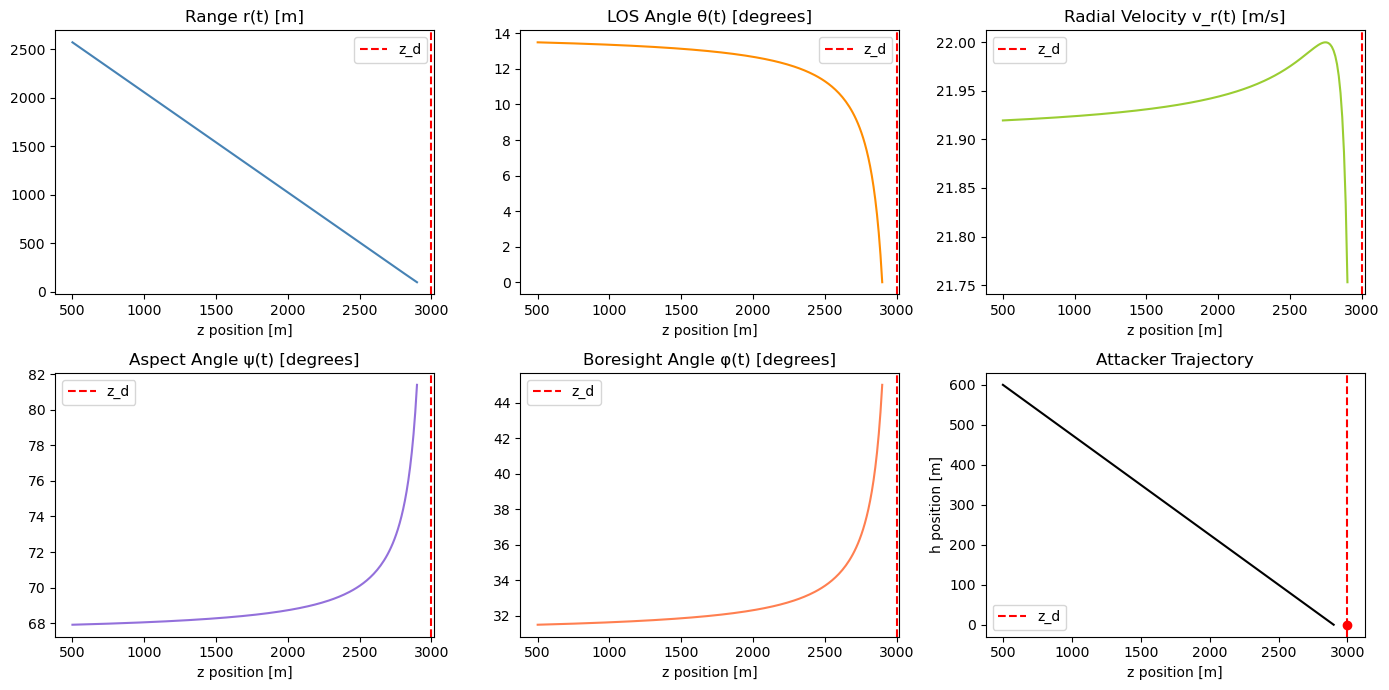

In [4]:
# Visualize how geometric quantities change as attacker approaches sensor
z_d = 3000.0
g_viz = Geometry(z_d=z_d, camera_elevation_deg=45.0)

# Straight-line approach at constant gamma -0.15 rad
gamma = -0.15
h_start = 600.0
z_vals = np.linspace(500.0, 2900.0, 200)
h_vals = h_start * (1 - (z_vals - 500.0) / (2900.0 - 500.0))  # Linear decrease

r_vals = [g_viz.range(z, h) for z, h, in zip(z_vals, h_vals)]
theta_vals = [np.degrees(g_viz.los_angle(z, h)) for z, h in zip(z_vals, h_vals)]
vr_vals = [g_viz.radial_velocity(z, h, 22.0, gamma) for z, h in zip(z_vals, h_vals)]
psi_vals = [g_viz.aspect_angle(z, h, gamma) for z, h in zip(z_vals, h_vals)]
phi_vals = [np.degrees(g_viz.boresight_angle(z, h)) for z, h in zip(z_vals, h_vals)]

# Geometric Quantities along approach trajectory
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes[0, 0].plot(z_vals, r_vals, color = 'steelblue')
axes[0, 0].set_title('Range r(t) [m]')
axes[0, 0].set_xlabel('z position [m]')
axes[0, 0].axvline(z_d, color="red", linestyle="--", label="z_d")
axes[0, 0].legend()

axes[0, 1].plot(z_vals, theta_vals, color = 'darkorange')
axes[0, 1].set_title('LOS Angle θ(t) [degrees]')
axes[0, 1].set_xlabel('z position [m]')
axes[0, 1].axvline(z_d, color="red", linestyle="--", label="z_d")
axes[0, 1].legend()

axes[0, 2].plot(z_vals, vr_vals, color = 'yellowgreen')
axes[0, 2].set_title('Radial Velocity v_r(t) [m/s]')
axes[0, 2].set_xlabel('z position [m]')
axes[0, 2].axvline(z_d, color="red", linestyle="--", label="z_d")
axes[0, 2].legend()

axes[1, 0].plot(z_vals, psi_vals, color = 'mediumpurple')
axes[1, 0].set_title('Aspect Angle ψ(t) [degrees]')
axes[1, 0].set_xlabel('z position [m]')
axes[1, 0].axvline(z_d, color="red", linestyle="--", label="z_d")
axes[1, 0].legend()

axes[1, 1].plot(z_vals, phi_vals, color = 'coral')
axes[1, 1].set_title('Boresight Angle φ(t) [degrees]')
axes[1, 1].set_xlabel('z position [m]')
axes[1, 1].axvline(z_d, color="red", linestyle="--", label="z_d")
axes[1, 1].legend()

axes[1, 2].plot(z_vals, h_vals, color = 'black')
axes[1, 2].axvline(z_d, color='red', linestyle='--', label='z_d')
axes[1, 2].scatter([z_d], [0], color='red')
axes[1, 2].set_title('Attacker Trajectory')
axes[1, 2].set_xlabel('z position [m]')
axes[1, 2].set_ylabel('h position [m]')
axes[1, 2].legend()

# Adjust layout
plt.tight_layout()

## SECTION 2 - Vehicle Test

Test for 'vehicle.py': polar precomputation, glide speed, delta budget, and trajectory simulation

In [5]:
print('=== Vehicle Tests ===')

vp = VehicleParams()
v = Vehicle(vp)

# --- polar precomputation ---
check('CL_star positive',
      v.CL_star > 0,
      f'CL_star = {v.CL_star:.4f}')

check('CD_star = 2*C_D0 (induced = parasitic at best glide)',
      abs(v.CD_star - 2*vp.airframe.C_D0) < 1e-9,
      f'CD_star = {v.CD_star:.6f}, 2*C_D0 = {2*vp.airframe.C_D0:.6f}')

check('LD_max positive',
      v.LD_max > 0,
      f'LD_max = {v.LD_max:.2f}')

check('gamma_star negaive (Descending)',
      v.gamma_star < 0,
      f'gamma_star = {np.degrees(v.gamma_star):.2f} degrees')

check('v_star positive',
      v.v_star > 0,
      f'v_star = {v.v_star:.2f} m/s')

# glide_speed at gamma_star should return v_star
v_at_best = v.glide_speed(v.gamma_star)
check('glide_speed(gamma_star) = v_star',
      abs(v_at_best - v.v_star) < 1,
      f'glide_speed(gamma_star) = {v_at_best:.2f} m/s, v_star = {v.v_star:.2f} m/s')


# --- glide speed direction ---
# On stable branch: steeper = fater, shallower = slower
v_steep = v.glide_speed(-0.5)
v_shallow = v.glide_speed(-0.1)
check('glide_speed: steeper gamma gives higher speed',
      v_steep > v_shallow,
      f'steep={v_steep:.2f} m/s, shallow={v_shallow:.2f} m/s')

# --- delta budget ---
delta_feasible = v.compute_delta(z_sw = 1000.0, h_sw = 600.0)
check('delta_budget: feasible switch point gives positive delta',
      delta_feasible > 0,
      f'delta_budget = {delta_feasible:.2f} m')

delta_infeasible = v.compute_delta(z_sw = 0.0, h_sw = 1.0)
check('delta_budget: infeasible switch point gives negative delta',
      delta_infeasible < 0,
      f'delta_budget = {delta_infeasible:.2f} m')

=== Vehicle Tests ===
[Grace of the Omnissiah, the holy data has passed the rite of validation] CL_star positive (CL_star = 0.7454)
[Grace of the Omnissiah, the holy data has passed the rite of validation] CD_star = 2*C_D0 (induced = parasitic at best glide) (CD_star = 0.050000, 2*C_D0 = 0.050000)
[Grace of the Omnissiah, the holy data has passed the rite of validation] LD_max positive (LD_max = 14.91)
[Grace of the Omnissiah, the holy data has passed the rite of validation] gamma_star negaive (Descending) (gamma_star = -3.84 degrees)
[Grace of the Omnissiah, the holy data has passed the rite of validation] v_star positive (v_star = 20.24 m/s)
[Grace of the Omnissiah, the holy data has passed the rite of validation] glide_speed(gamma_star) = v_star (glide_speed(gamma_star) = 20.24 m/s, v_star = 20.24 m/s)
[Grace of the Omnissiah, the holy data has passed the rite of validation] glide_speed: steeper gamma gives higher speed (steep=76.47 m/s, shallow=32.65 m/s)
[Grace of the Omnissiah, t

True

In [6]:
# --- simulated powered phase on infeasible ---
try:
    v.simulate_powered(h_dot=3.0, h_sw=1.0) # h_sw  is too small
    check('simulated_powered: raises ValueError for infeasible', False)
except ValueError as e:
    check('simulated_powered: raises ValueError for infeasible', True, str(e)[:60])

# --- simulate produces valid trajectory ---
traj = v.simulate(h_dot=3.0, h_sw=600.0, gamma=-0.2)
check('simulate: returns non-empty trajectory',
      len(traj) > 1,
      f'{len(traj)} points')

phases = [p.phase for p in traj]
check('simulate: both phases present',
      1 in phases and 2 in phases,
      f'phases found: {set(phases)}')

# Phase 1 before Phase 2, no return
transition = next(i for i, p in enumerate(traj) if p.phase == 2)
check('simulate: phase 1 before phase 2',
      all(p.phase == 1 for p in traj[:transition]) and all(p.phase == 2 for p in traj[transition:]),
      f'phase sequence: {[p.phase for p in traj]}')

# altitude non-increasing in glide
glide_pts = [p for p in traj if p.phase == 2]
alts = [p.h for p in glide_pts]
check('simulate: altitude non-increasing in glide',
      all(alts[i] >= alts[i+1]-1e-6 for i in range(len(alts)-1)))

# final altitude near ground
check('simulate: final altitude near ground',
      traj[-1].h < 5.0,
      f'final h = {traj[-1].h:.2f} m')

# delta_remainig non-increasing in glide
dr = [p.delta_remaining for p in glide_pts]
check('simulate: delta_remaining non-increasing in glide',
      all(dr[i] >= dr[i+1]-1e-6 for i in range(len(dr)-1)),
      f'initial={dr[0]:.2f} m, final={dr[-1]:.2f} m')

# total time positive
T = v.total_time(traj)
check('total_time: positive',
      T > 0,
      f'T = {T:.2f} s')

# to_arrays returns correct shapes
arrays = v.to_arrays(traj)
n = len(traj)
check('to_arrays: all arrays have correct length',
      all(arrays[k].shape == (n,) for k in ['t', 'z', 'h', 'v', 'gamma', 'phase', 'delta_remaining']),
      f'n = {n}')

[Grace of the Omnissiah, the holy data has passed the rite of validation] simulated_powered: raises ValueError for infeasible (Infeasible: Delta=-4976.8 m,Cannot reach z_goal from (z_sw=8)
[Grace of the Omnissiah, the holy data has passed the rite of validation] simulate: returns non-empty trajectory (402 points)
[Grace of the Omnissiah, the holy data has passed the rite of validation] simulate: both phases present (phases found: {1, 2})
[Grace of the Omnissiah, the holy data has passed the rite of validation] simulate: phase 1 before phase 2 (phase sequence: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

True

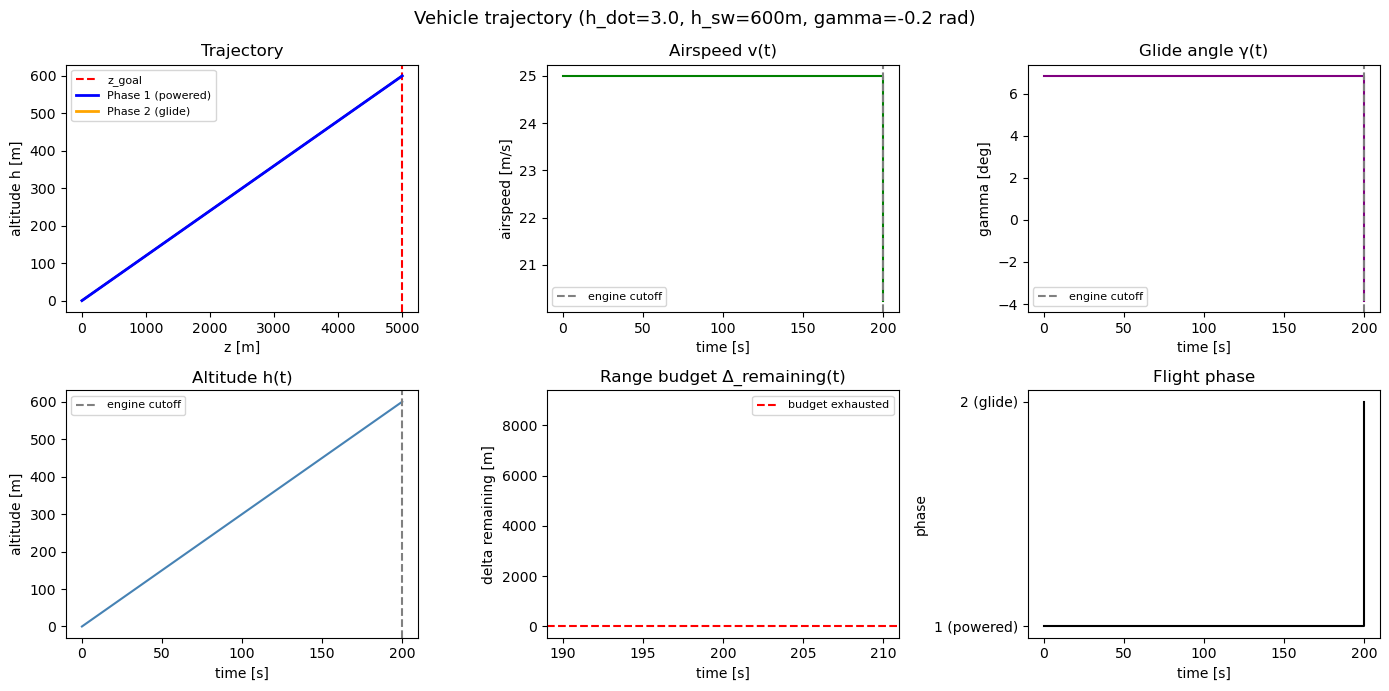

In [7]:
# Visualize a full trajectory
traj_viz = v.simulate(h_dot=3.0, h_sw=600.0, gamma=-0.2)
arr      = v.to_arrays(traj_viz)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Vehicle trajectory (h_dot=3.0, h_sw=600m, gamma=-0.2 rad)", fontsize=13)

# Trajectory shape
axes[0,0].plot(arr["z"], arr["h"], color="black")
axes[0,0].axvline(vp.z_goal, color="red", linestyle="--", label="z_goal")
phase1_mask = arr["phase"] == 1
phase2_mask = arr["phase"] == 2
axes[0,0].plot(arr["z"][phase1_mask], arr["h"][phase1_mask],
               color="blue", linewidth=2, label="Phase 1 (powered)")
axes[0,0].plot(arr["z"][phase2_mask], arr["h"][phase2_mask],
               color="orange", linewidth=2, label="Phase 2 (glide)")
axes[0,0].set_xlabel("z [m]")
axes[0,0].set_ylabel("altitude h [m]")
axes[0,0].set_title("Trajectory")
axes[0,0].legend(fontsize=8)

# Airspeed over time
axes[0,1].plot(arr["t"], arr["v"], color="green")
axes[0,1].axvline(arr["t"][np.argmax(arr["phase"] == 2)],
                  color="gray", linestyle="--", label="engine cutoff")
axes[0,1].set_xlabel("time [s]")
axes[0,1].set_ylabel("airspeed [m/s]")
axes[0,1].set_title("Airspeed v(t)")
axes[0,1].legend(fontsize=8)

# Gamma over time
axes[0,2].plot(arr["t"], np.degrees(arr["gamma"]), color="purple")
axes[0,2].axvline(arr["t"][np.argmax(arr["phase"] == 2)],
                  color="gray", linestyle="--", label="engine cutoff")
axes[0,2].set_xlabel("time [s]")
axes[0,2].set_ylabel("gamma [deg]")
axes[0,2].set_title("Glide angle γ(t)")
axes[0,2].legend(fontsize=8)

# Altitude over time
axes[1,0].plot(arr["t"], arr["h"], color="steelblue")
axes[1,0].axvline(arr["t"][np.argmax(arr["phase"] == 2)],
                  color="gray", linestyle="--", label="engine cutoff")
axes[1,0].set_xlabel("time [s]")
axes[1,0].set_ylabel("altitude [m]")
axes[1,0].set_title("Altitude h(t)")
axes[1,0].legend(fontsize=8)

# Delta remaining (glide phase only)
t_glide  = arr["t"][phase2_mask]
dr_glide = arr["delta_remaining"][phase2_mask]
axes[1,1].plot(t_glide, dr_glide, color="darkorange")
axes[1,1].set_xlabel("time [s]")
axes[1,1].set_ylabel("delta remaining [m]")
axes[1,1].set_title("Range budget Δ_remaining(t)")
axes[1,1].axhline(0, color="red", linestyle="--", label="budget exhausted")
axes[1,1].legend(fontsize=8)

# Phase indicator
axes[1,2].step(arr["t"], arr["phase"], color="black", where="post")
axes[1,2].set_xlabel("time [s]")
axes[1,2].set_ylabel("phase")
axes[1,2].set_yticks([1, 2])
axes[1,2].set_yticklabels(["1 (powered)", "2 (glide)"])
axes[1,2].set_title("Flight phase")

plt.tight_layout()
plt.show()

## Section 3 — Sensor Tests

Tests for `sensors.py`: individual sensor PoD rates,
phase gating, RCS model, and sensor suite assembly.

In [8]:
print("=== Sensor Tests ===\n")

z_d_test = 3000.0
geom     = Geometry(z_d=z_d_test)

# --- acoustic ---
ac = AcousticSensor()

check("acoustic: zero in glide phase",
      ac.pod_rate(1000, 500, 25, -0.15, geom, phase=2) == 0.0)

rate_powered = ac.pod_rate(1000, 500, 25, -0.15, geom, phase=1)
check("acoustic: positive in powered phase",
      rate_powered > 0,
      f"rate = {rate_powered:.4e}")

rate_slow = ac.pod_rate(1000, 500, 15, -0.15, geom, phase=1)
rate_fast = ac.pod_rate(1000, 500, 30, -0.15, geom, phase=1)
check("acoustic: faster speed gives higher rate",
      rate_fast > rate_slow,
      f"slow={rate_slow:.4e}, fast={rate_fast:.4e}")

rate_far  = ac.pod_rate(500,  500, 25, -0.15, geom, phase=1)
rate_near = ac.pod_rate(2800, 100, 25, -0.15, geom, phase=1)
check("acoustic: closer to sensor gives higher rate",
      rate_near > rate_far,
      f"far={rate_far:.4e}, near={rate_near:.4e}")

# --- doppler ---
dopp = DopplerSensor()

rate_p1 = dopp.pod_rate(1500, 500, 22, -0.15, geom, phase=1)
rate_p2 = dopp.pod_rate(1500, 500, 22, -0.15, geom, phase=2)
check("doppler: active in powered phase",  rate_p1 > 0, f"{rate_p1:.4e}")
check("doppler: active in glide phase",    rate_p2 > 0, f"{rate_p2:.4e}")

# --- RCS ---
rcs = RCSSensor()

check("RCS model: sigma(90 deg) = 1.0 (maximum)",
      abs(rcs.rcs(90.0) - 1.0) < 1e-9,
      f"sigma(90) = {rcs.rcs(90.0):.8f}")

check("RCS model: decreases away from 90 deg (left side)",
      rcs.rcs(90) > rcs.rcs(60) > rcs.rcs(30),
      f"90={rcs.rcs(90):.3f}, 60={rcs.rcs(60):.3f}, 30={rcs.rcs(30):.3f}")

check("RCS model: decreases away from 90 deg (right side)",
      rcs.rcs(90) > rcs.rcs(120) > rcs.rcs(150),
      f"90={rcs.rcs(90):.3f}, 120={rcs.rcs(120):.3f}, 150={rcs.rcs(150):.3f}")

rate_rcs_p1 = rcs.pod_rate(1500, 500, 22, -0.15, geom, phase=1)
rate_rcs_p2 = rcs.pod_rate(1500, 500, 22, -0.15, geom, phase=2)
check("RCS: active in powered phase", rate_rcs_p1 > 0, f"{rate_rcs_p1:.4e}")
check("RCS: active in glide phase",   rate_rcs_p2 > 0, f"{rate_rcs_p2:.4e}")

# --- camera ---
cam = CameraSensor()

# Attacker behind sensor — opposite direction from boresight — outside FOV
rate_behind = cam.pod_rate(5000, 10, 22, -0.15, geom, phase=2)
check("camera: zero when attacker behind sensor (outside FOV)",
      rate_behind == 0.0,
      f"rate = {rate_behind:.4e}")

# Attacker along boresight direction — should be maximum
t_dist  = 300.0
z_along = z_d_test - t_dist * np.cos(np.radians(45))
h_along = t_dist * np.sin(np.radians(45))
rate_on_boresight = cam.pod_rate(z_along, h_along, 22, -0.15, geom, phase=2)
check("camera: positive when attacker along boresight",
      rate_on_boresight > 0,
      f"rate = {rate_on_boresight:.4e}")

# --- sensor suite ---
suite = SensorSuite(z_d=z_d_test)

individual = suite.individual_pod_rates(1500, 600, 22, -0.15, phase=1)
total      = suite.total_pod_rate(1500, 600, 22, -0.15, phase=1)

check("suite: total = sum of individual rates",
      abs(total - sum(individual.values())) < 1e-12,
      f"total={total:.6e}, sum={sum(individual.values()):.6e}")

check("suite: all individual rates non-negative",
      all(v >= 0 for v in individual.values()),
      str({k: f"{v:.3e}" for k, v in individual.items()}))

print(f"\n  Individual rates at (z=1500, h=600, v=22, gamma=-0.15, phase=1):")
for k, val in individual.items():
    print(f"    {k:12s}: {val:.4e}")

=== Sensor Tests ===

[Grace of the Omnissiah, the holy data has passed the rite of validation] acoustic: zero in glide phase
[Grace of the Omnissiah, the holy data has passed the rite of validation] acoustic: positive in powered phase (rate = 5.7445e-03)
[Grace of the Omnissiah, the holy data has passed the rite of validation] acoustic: faster speed gives higher rate (slow=2.6801e-04, fast=1.7153e-02)
[Grace of the Omnissiah, the holy data has passed the rite of validation] acoustic: closer to sensor gives higher rate (far=3.7560e-03, near=4.8828e-01)
[Grace of the Omnissiah, the holy data has passed the rite of validation] doppler: active in powered phase (7.5178e-17)
[Grace of the Omnissiah, the holy data has passed the rite of validation] doppler: active in glide phase (7.5178e-17)
[Grace of the Omnissiah, the holy data has passed the rite of validation] RCS model: sigma(90 deg) = 1.0 (maximum) (sigma(90) = 1.00000000)
[Grace of the Omnissiah, the holy data has passed the rite of v

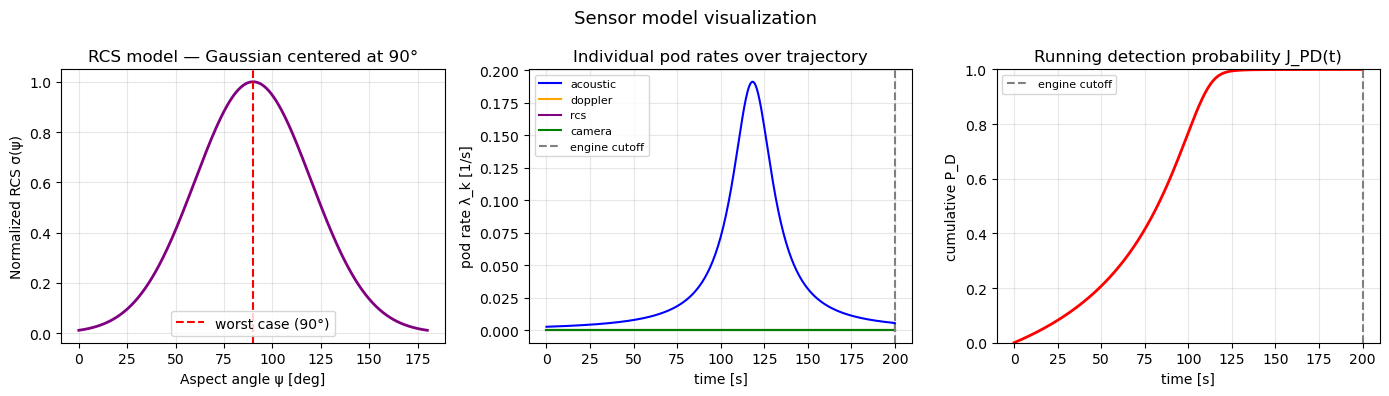

In [9]:
# Visualize RCS model and pod rates along a trajectory
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Sensor model visualization", fontsize=13)

# RCS vs aspect angle
psi_range = np.linspace(0, 180, 300)
rcs_model = RCSSensor()
sigma_vals = [rcs_model.rcs(p) for p in psi_range]

axes[0].plot(psi_range, sigma_vals, color="purple", linewidth=2)
axes[0].axvline(90, color="red", linestyle="--", label="worst case (90°)")
axes[0].set_xlabel("Aspect angle ψ [deg]")
axes[0].set_ylabel("Normalized RCS σ(ψ)")
axes[0].set_title("RCS model — Gaussian centered at 90°")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# All four sensor pod rates along the trajectory we simulated earlier
suite_viz = SensorSuite(z_d=3000.0)
traj_s    = v.simulate(h_dot=3.0, h_sw=600.0, gamma=-0.2)
arr_s     = v.to_arrays(traj_s)
game_tmp  = Game()
rates_arr = game_tmp.get_individual_pod_arrays(traj_s, z_d=3000.0)

cutoff_t = arr_s["t"][np.argmax(arr_s["phase"] == 2)]

for sensor, color in [("acoustic","blue"),("doppler","orange"),
                       ("rcs","purple"),("camera","green")]:
    axes[1].plot(arr_s["t"], rates_arr[sensor],
                 label=sensor, color=color, linewidth=1.5)
axes[1].axvline(cutoff_t, color="gray", linestyle="--", label="engine cutoff")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("pod rate λ_k [1/s]")
axes[1].set_title("Individual pod rates over trajectory")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Cumulative integrated pod (running integral)
dt        = np.diff(arr_s["t"])
total_r   = sum(rates_arr[k] for k in rates_arr)
running   = np.concatenate([[0], np.cumsum(0.5*(total_r[:-1]+total_r[1:])*dt)])
J_PD_running = 1 - np.exp(-running)

axes[2].plot(arr_s["t"], J_PD_running, color="red", linewidth=2)
axes[2].axvline(cutoff_t, color="gray", linestyle="--", label="engine cutoff")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("cumulative P_D")
axes[2].set_title("Running detection probability J_PD(t)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Section 4 — Game Tests

Tests for `game.py`: J_PD, J_A, J_D evaluation,
cost function bounds, and delta reporting.

In [10]:
print("=== Game Tests ===\n")

game = Game()

result = game.evaluate(h_dot=3.0, h_sw=600.0, gamma=-0.2, z_d=3000.0)

check("evaluate: J_PD in [0, 1]",
      0.0 <= result["J_PD"] <= 1.0,
      f"J_PD = {result['J_PD']:.4f}")

check("evaluate: J_A in [0, 1]",
      0.0 <= result["J_A"] <= 1.0,
      f"J_A = {result['J_A']:.4f}")

check("evaluate: J_D in [0, 1]",
      0.0 <= result["J_D"] <= 1.0,
      f"J_D = {result['J_D']:.4f}")

check("evaluate: T positive",
      result["T"] > 0,
      f"T = {result['T']:.1f} s")

check("evaluate: delta in result",
      "delta" in result,
      f"delta = {result['delta']:.1f} m")

check("evaluate: delta positive for this trajectory",
      result["delta"] > 0)

# Different z_d should give different J_PD
r1 = game.evaluate(3.0, 600.0, -0.2, z_d=500.0)
r2 = game.evaluate(3.0, 600.0, -0.2, z_d=4000.0)
check("evaluate: different z_d gives different J_PD",
      r1["J_PD"] != r2["J_PD"],
      f"z_d=500: {r1['J_PD']:.4f}, z_d=4000: {r2['J_PD']:.4f}")

# Coverage score
c_mid  = game._coverage_score((game.vp.z_start + game.vp.z_goal) / 2)
c_end  = game._coverage_score(game.vp.z_goal - 1)
check("coverage: maximum at midpoint",
      abs(c_mid - 1.0) < 1e-6,
      f"C(midpoint) = {c_mid:.4f}")
check("coverage: near zero at corridor end",
      c_end < 0.05,
      f"C(z_goal-1) = {c_end:.4f}")

# Individual pod arrays
rates = game.get_individual_pod_arrays(result["trajectory"], z_d=3000.0)
n     = len(result["trajectory"])
check("get_individual_pod_arrays: correct shape",
      all(rates[k].shape == (n,) for k in rates),
      f"n = {n}")
check("get_individual_pod_arrays: all non-negative",
      all(np.all(rates[k] >= 0) for k in rates))

print(f"\n  Summary at (h_dot=3.0, h_sw=600, gamma=-0.2, z_d=3000):")
print(f"    J_PD  = {result['J_PD']:.4f}")
print(f"    J_A   = {result['J_A']:.4f}")
print(f"    J_D   = {result['J_D']:.4f}")
print(f"    T     = {result['T']:.1f} s")
print(f"    delta = {result['delta']:.1f} m")

=== Game Tests ===

[Grace of the Omnissiah, the holy data has passed the rite of validation] evaluate: J_PD in [0, 1] (J_PD = 0.9996)
[Grace of the Omnissiah, the holy data has passed the rite of validation] evaluate: J_A in [0, 1] (J_A = 0.9426)
[Grace of the Omnissiah, the holy data has passed the rite of validation] evaluate: J_D in [0, 1] (J_D = 0.9596)
[Grace of the Omnissiah, the holy data has passed the rite of validation] evaluate: T positive (T = 200.0 s)
[Grace of the Omnissiah, the holy data has passed the rite of validation] evaluate: delta in result (delta = 8944.3 m)
[Grace of the Omnissiah, the holy data has passed the rite of validation] evaluate: delta positive for this trajectory
[Grace of the Omnissiah, the holy data has passed the rite of validation] evaluate: different z_d gives different J_PD (z_d=500: 1.0000, z_d=4000: 0.9950)
[Grace of the Omnissiah, the holy data has passed the rite of validation] coverage: maximum at midpoint (C(midpoint) = 1.0000)
[Grace of 

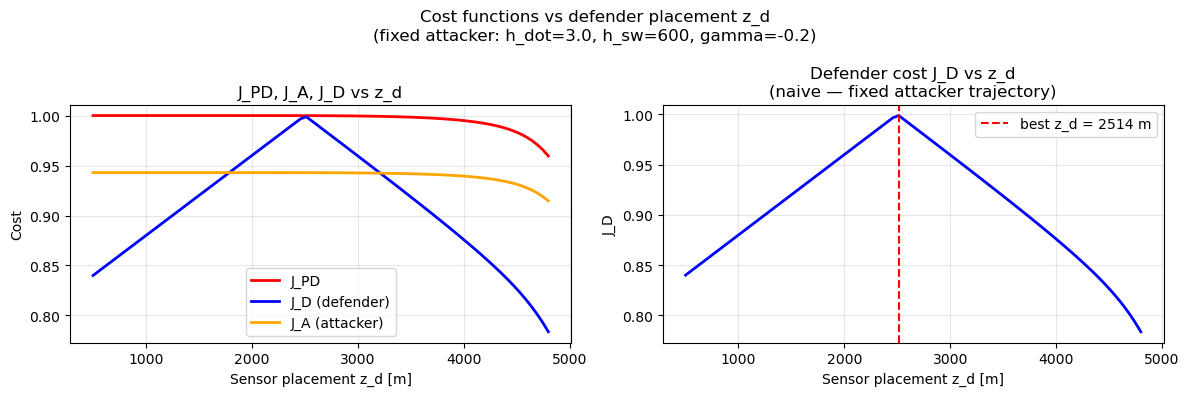

Best z_d (naive sweep): 2514 m
J_D at best z_d:        0.9988


In [11]:
# Sweep z_d to see how detection probability changes with sensor placement
# for a fixed attacker trajectory
z_d_sweep = np.linspace(500, 4800, 80)
J_PD_vals = []
J_D_vals  = []
J_A_vals  = []

for z_d_val in z_d_sweep:
    r = game.evaluate(h_dot=3.0, h_sw=600.0, gamma=-0.2, z_d=z_d_val)
    J_PD_vals.append(r["J_PD"])
    J_D_vals.append(r["J_D"])
    J_A_vals.append(r["J_A"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Cost functions vs defender placement z_d\n"
             "(fixed attacker: h_dot=3.0, h_sw=600, gamma=-0.2)", fontsize=12)

axes[0].plot(z_d_sweep, J_PD_vals, color="red",    label="J_PD", linewidth=2)
axes[0].plot(z_d_sweep, J_D_vals,  color="blue",   label="J_D (defender)", linewidth=2)
axes[0].plot(z_d_sweep, J_A_vals,  color="orange", label="J_A (attacker)", linewidth=2)
axes[0].set_xlabel("Sensor placement z_d [m]")
axes[0].set_ylabel("Cost")
axes[0].set_title("J_PD, J_A, J_D vs z_d")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(z_d_sweep, J_D_vals, color="blue", linewidth=2)
best_idx = np.argmax(J_D_vals)
axes[1].axvline(z_d_sweep[best_idx], color="red", linestyle="--",
                label=f"best z_d = {z_d_sweep[best_idx]:.0f} m")
axes[1].set_xlabel("Sensor placement z_d [m]")
axes[1].set_ylabel("J_D")
axes[1].set_title("Defender cost J_D vs z_d\n(naive — fixed attacker trajectory)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best z_d (naive sweep): {z_d_sweep[best_idx]:.0f} m")
print(f"J_D at best z_d:        {J_D_vals[best_idx]:.4f}")

## Section 5 — Attacker Best Response (Traditional Optimizer)

Tests `attacker_best_response` for a fixed z_d.
This is Step 2 of the solution plan — the non-RL baseline.

In [12]:
print("=== Attacker Best Response (Traditional Optimizer) ===\n")
print("Running Nelder-Mead for z_d = 3000 m ...")

br = game.attacker_best_response(z_d=3000.0, verbose=True)

print(f"\n  Optimal attacker decisions:")
print(f"    h_dot  = {br['h_dot']:.3f} m/s")
print(f"    h_sw   = {br['h_sw']:.1f} m")
print(f"    z_sw   = {br['z_sw']:.1f} m")
print(f"    gamma  = {np.degrees(br['gamma']):.2f} deg")
print(f"    delta  = {br['delta']:.1f} m")
print(f"\n  Costs:")
print(f"    J_PD   = {br['J_PD']:.4f}")
print(f"    J_A    = {br['J_A']:.4f}")
print(f"    T      = {br['T']:.1f} s")
print(f"\n  Optimizer:")
print(f"    success  = {br['success']}")
print(f"    n_evals  = {br['n_evals']}")

check("attacker BR: J_PD in [0, 1]",
      0 <= br["J_PD"] <= 1.0)
check("attacker BR: J_A in [0, 1]",
      0 <= br["J_A"]  <= 1.0)
check("attacker BR: delta >= 0 (feasible trajectory)",
      br["delta"] >= 0,
      f"delta = {br['delta']:.1f} m")
check("attacker BR: optimizer ran",
      br["n_evals"] > 0)

# Compare BR trajectory against a naive trajectory
# naive = game.evaluate(h_dot=3.0, h_sw=600.0,
#                        gamma=(game.vp.gamma_min + game.vp.gamma_max)/2,
#                        z_d=3000.0)

def required_gamma(vehicle, h_sw, h_dot):
    vp    = vehicle.p
    t_c   = h_sw / h_dot
    z_sw  = vp.z_start + vp.v_climb * t_c
    dz    = vp.z_goal - z_sw
    if dz <= 0:
        return vp.gamma_min
    gamma_req = -np.arctan(h_sw / dz)
    return np.clip(gamma_req, vp.gamma_min, vp.gamma_max)
# Naive: fixed parameters, no optimization
# Climbs steeply and early, glides at a moderate fixed angle
# This is what an unsophisticated attacker would do

h_dot_naive = game.vp.h_dot_max           # climb as fast as possible
h_sw_naive  = 500.0                        # modest altitude
gamma_naive = np.radians(-15.0)           # moderate glide, not optimized

# Check feasibility
t_c   = h_sw_naive / h_dot_naive
z_sw_n = game.vp.z_start + game.vp.v_climb * t_c
delta_n = game.vehicle.compute_delta(z_sw_n, h_sw_naive)
print(f"Naive: z_sw={z_sw_n:.1f} m, h_sw={h_sw_naive:.1f} m, "
      f"gamma={np.degrees(gamma_naive):.1f} deg, delta={delta_n:.1f} m")

naive = game.evaluate(
    h_dot  = h_dot_naive,
    h_sw   = h_sw_naive,
    gamma  = gamma_naive,
    z_d    = 3000.0
)

print(f"Naive J_A={naive['J_A']:.4f}, J_PD={naive['J_PD']:.4f}")

check("attacker BR: J_A lower than naive trajectory",
      br["J_A"] <= naive["J_A"] + 1e-4,
      f"BR J_A={br['J_A']:.4f}, naive J_A={naive['J_A']:.4f}")

=== Attacker Best Response (Traditional Optimizer) ===

Running Nelder-Mead for z_d = 3000 m ...


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Optimization terminated successfully.
         Current function value: 0.593966
         Iterations: 98
         Function evaluations: 225

  Optimal attacker decisions:
    h_dot  = 2.563 m/s
    h_sw   = 202.8 m
    z_sw   = 1977.5 m
    gamma  = -23.33 deg
    delta  = 0.0 m

  Costs:
    J_PD   = 0.4677
    J_A    = 0.5940
    T      = 219.5 s

  Optimizer:
    success  = True
    n_evals  = 225
[Grace of the Omnissiah, the holy data has passed the rite of validation] attacker BR: J_PD in [0, 1]
[Grace of the Omnissiah, the holy data has passed the rite of validation] attacker BR: J_A in [0, 1]
[Grace of the Omnissiah, the holy data has passed the rite of validation] attacker BR: delta >= 0 (feasible trajectory) (delta = 0.0 m)
[Grace of the Omnissiah, the holy data has passed the rite of validation] attacker BR: optimizer ran
Naive: z_sw=2500.0 m, h_sw=500.0 m, gamma=-15.0 deg, delta=4953.6 m
Naive J_A=0.7109, J_PD=0.7215
[Grace of the Omnissiah, the holy data has passed the rite 

True

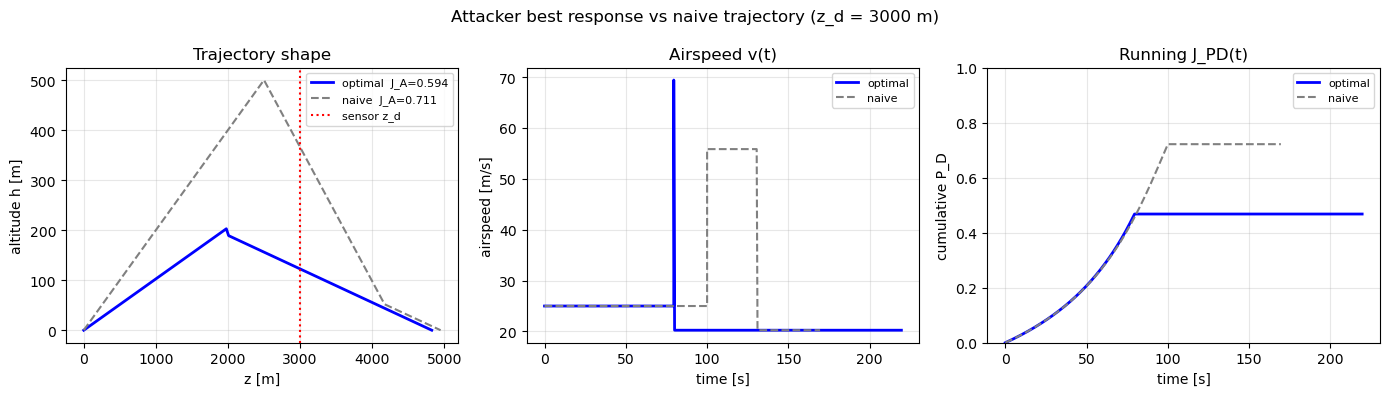

In [13]:
# Plot the optimal attacker trajectory vs naive
traj_br    = br["full_result"]["trajectory"]
arr_br     = game.vehicle.to_arrays(traj_br)

traj_naive = naive["trajectory"]
arr_naive  = game.vehicle.to_arrays(traj_naive)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Attacker best response vs naive trajectory (z_d = 3000 m)",
             fontsize=12)

# Trajectory shape
axes[0].plot(arr_br["z"],    arr_br["h"],    color="blue",
             linewidth=2, label=f"optimal  J_A={br['J_A']:.3f}")
axes[0].plot(arr_naive["z"], arr_naive["h"], color="gray",
             linewidth=1.5, linestyle="--",
             label=f"naive  J_A={naive['J_A']:.3f}")
axes[0].axvline(3000.0, color="red", linestyle=":", label="sensor z_d")
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("altitude h [m]")
axes[0].set_title("Trajectory shape")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Airspeed
axes[1].plot(arr_br["t"],    arr_br["v"],    color="blue",  linewidth=2, label="optimal")
axes[1].plot(arr_naive["t"], arr_naive["v"], color="gray",  linewidth=1.5,
             linestyle="--", label="naive")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("airspeed [m/s]")
axes[1].set_title("Airspeed v(t)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Cumulative detection probability
rates_br    = game.get_individual_pod_arrays(traj_br,    z_d=3000.0)
rates_naive = game.get_individual_pod_arrays(traj_naive, z_d=3000.0)

def running_jpd(arr, rates):
    dt     = np.diff(arr["t"])
    total  = sum(rates[k] for k in rates)
    cumint = np.concatenate([[0],
                              np.cumsum(0.5*(total[:-1]+total[1:])*dt)])
    return 1 - np.exp(-cumint)

jpd_br    = running_jpd(arr_br,    rates_br)
jpd_naive = running_jpd(arr_naive, rates_naive)

axes[2].plot(arr_br["t"],    jpd_br,    color="blue", linewidth=2, label="optimal")
axes[2].plot(arr_naive["t"], jpd_naive, color="gray", linewidth=1.5,
             linestyle="--", label="naive")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("cumulative P_D")
axes[2].set_title("Running J_PD(t)")
axes[2].set_ylim([0, 1])
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Add this after Cell 13 to diagnose
glide_pts = [(i, p) for i, p in enumerate(traj_br) if p.phase == 2]
print("Individual pod rates during glide phase (first 5 points):")
for i, p in glide_pts[:5]:
    rates = game.get_individual_pod_arrays([p], z_d=3000.0)
    print(f"  t={p.t:.1f}s z={p.z:.0f}m h={p.h:.1f}m: "
          f"doppler={rates['doppler'][0]:.3e} "
          f"rcs={rates['rcs'][0]:.3e} "
          f"camera={rates['camera'][0]:.3e}")

Individual pod rates during glide phase (first 5 points):
  t=79.5s z=1978m h=202.8m: doppler=3.902e-15 rcs=4.365e-19 camera=3.179e-11
  t=80.0s z=2009m h=189.0m: doppler=3.903e-16 rcs=8.582e-19 camera=3.363e-11
  t=80.5s z=2019m h=188.3m: doppler=4.062e-16 rcs=8.923e-19 camera=3.437e-11
  t=81.0s z=2030m h=187.7m: doppler=4.228e-16 rcs=9.280e-19 camera=3.513e-11
  t=81.5s z=2040m h=187.0m: doppler=4.403e-16 rcs=9.655e-19 camera=3.592e-11


## Section 6 — Defender Best Placement (Grid Search)

Runs `defender_best_placement` over a grid of z_d values.
This is Step 7 of the solution plan.
Each z_d queries attacker_best_response — so this is the full
traditional Stackelberg solution.

Note: this cell takes a few minutes to run.

In [15]:
print("=== Defender Best Placement (Grid Search) ===\n")
print("Running grid search over z_d (n_grid=20 for speed)...\n")

stackelberg = game.defender_best_response(n_grid=20, verbose=True)

print(f"\n  Stackelberg equilibrium:")
print(f"    z_d*   = {stackelberg['z_d_star']:.0f} m")
print(f"    J_D*   = {stackelberg['J_D_star']:.4f}")

best_br = stackelberg["best"]["attacker_response"]
print(f"\n  Attacker best response at z_d*:")
print(f"    h_dot  = {best_br['h_dot']:.3f} m/s")
print(f"    h_sw   = {best_br['h_sw']:.1f} m")
print(f"    gamma  = {np.degrees(best_br['gamma']):.2f} deg")
print(f"    J_A    = {best_br['J_A']:.4f}")
print(f"    J_PD   = {best_br['J_PD']:.4f}")

=== Defender Best Placement (Grid Search) ===

Running grid search over z_d (n_grid=20 for speed)...

[1/20] z_d = 250... J_A = 0.9666, J_D = 0.8200
[2/20] z_d = 487... J_A = 0.9666, J_D = 0.8389
[3/20] z_d = 724... J_A = 0.9666, J_D = 0.8579
[4/20] z_d = 961... J_A = 0.9666, J_D = 0.8768
[5/20] z_d = 1197... J_A = 0.9666, J_D = 0.8958
[6/20] z_d = 1434... J_A = 0.9666, J_D = 0.9147
[7/20] z_d = 1671... J_A = 0.9666, J_D = 0.9337
[8/20] z_d = 1908... J_A = 0.9666, J_D = 0.9526
[9/20] z_d = 2145... J_A = 0.9545, J_D = 0.9577
[10/20] z_d = 2382... J_A = 0.8627, J_D = 0.8718
[11/20] z_d = 2618... J_A = 0.7419, J_D = 0.7337
[12/20] z_d = 2855... J_A = 0.6423, J_D = 0.6009
[13/20] z_d = 3092... J_A = 0.5675, J_D = 0.4965
[14/20] z_d = 3329... J_A = 0.5118, J_D = 0.4140
[15/20] z_d = 3566... J_A = 0.4698, J_D = 0.3470
[16/20] z_d = 3803... J_A = 0.4376, J_D = 0.2912
[17/20] z_d = 4039... J_A = 0.4123, J_D = 0.2434
[18/20] z_d = 4276... J_A = 0.3922, J_D = 0.2014
[19/20] z_d = 4513... J_A = 0

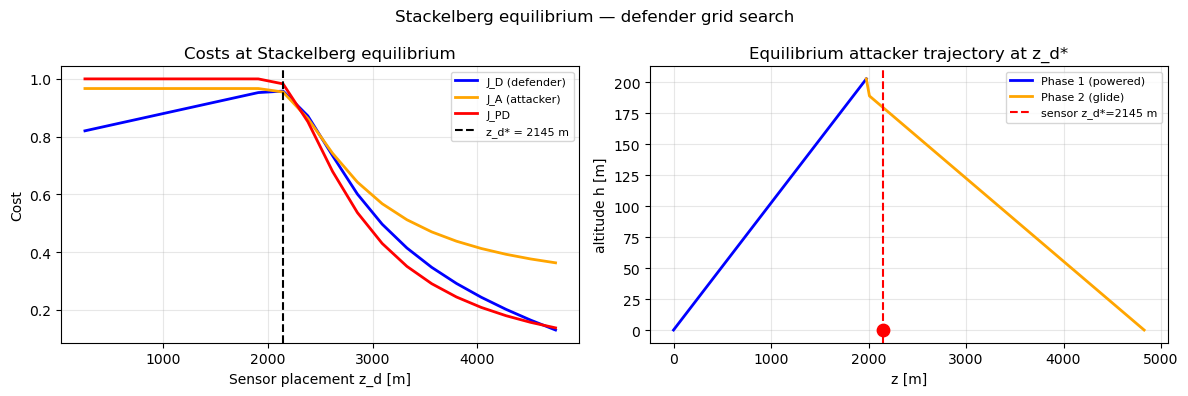

In [16]:
all_r   = stackelberg["all_results"]
z_d_arr = np.array([r["z_d"]  for r in all_r])
J_D_arr = np.array([r["J_D"]  for r in all_r])
J_A_arr = np.array([r["J_A"]  for r in all_r])
J_PD_arr= np.array([r["J_PD"] for r in all_r])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Stackelberg equilibrium — defender grid search", fontsize=12)

axes[0].plot(z_d_arr, J_D_arr,  color="blue",   linewidth=2, label="J_D (defender)")
axes[0].plot(z_d_arr, J_A_arr,  color="orange", linewidth=2, label="J_A (attacker)")
axes[0].plot(z_d_arr, J_PD_arr, color="red",    linewidth=2, label="J_PD")
axes[0].axvline(stackelberg["z_d_star"], color="black",
                linestyle="--", label=f"z_d* = {stackelberg['z_d_star']:.0f} m")
axes[0].set_xlabel("Sensor placement z_d [m]")
axes[0].set_ylabel("Cost")
axes[0].set_title("Costs at Stackelberg equilibrium")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Optimal attacker trajectory at z_d*
traj_eq  = best_br["full_result"]["trajectory"]
arr_eq   = game.vehicle.to_arrays(traj_eq)
phase1_m = arr_eq["phase"] == 1
phase2_m = arr_eq["phase"] == 2

axes[1].plot(arr_eq["z"][phase1_m], arr_eq["h"][phase1_m],
             color="blue", linewidth=2, label="Phase 1 (powered)")
axes[1].plot(arr_eq["z"][phase2_m], arr_eq["h"][phase2_m],
             color="orange", linewidth=2, label="Phase 2 (glide)")
axes[1].axvline(stackelberg["z_d_star"], color="red",
                linestyle="--", label=f"sensor z_d*={stackelberg['z_d_star']:.0f} m")
axes[1].scatter([stackelberg["z_d_star"]], [0],
                color="red", zorder=5, s=80)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("altitude h [m]")
axes[1].set_title("Equilibrium attacker trajectory at z_d*")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# ── Dive-bombing trajectory ──────────────────────────────────────────────────
# Strategy: climb as high as feasibility allows, glide shallow until close,
# then dive steeply at -75 deg into z_goal.
gamma_shallow  = game.vp.gamma_max          # ~ -2 deg
gamma_dive     = -85.0 * np.pi / 180.0      # -75 deg
h_dot_dive     = game.vp.h_dot_max          # max climb rate

vp = game.vp
v  = game.vehicle

# For dive-bombing, h_sw is constrained by the terminal dive geometry.
# The dive from h_sw at -75 deg needs h_sw * cot(75) horizontal meters.
# We want the dive to start close to z_goal, so:
#   z_sw + h_sw * cot(75) <= z_goal
# Also z_sw = z_start + v_climb * (h_sw / h_dot)
# Substituting:
#   z_start + v_climb*(h_sw/h_dot) + h_sw*cot(75) <= z_goal
#   h_sw * (v_climb/h_dot + cot(75)) <= z_goal - z_start
#   h_sw <= (z_goal - z_start) / (v_climb/h_dot + cot(75))

cot_75    = 1.0 / np.tan(abs(gamma_dive))
h_sw_dive = (vp.z_goal - vp.z_start) / (vp.v_climb / h_dot_dive + cot_75)
h_sw_dive = float(h_sw_dive) * 0.9   # 10% margin so delta > 0

gamma_req_dive = required_gamma(game.vehicle, h_sw=h_sw_dive, h_dot=h_dot_dive)
print(f"Dive-bombing required gamma: {np.degrees(gamma_req_dive):.2f} deg")

# gamma_shallow must be at least as steep as required gamma
# take whichever is steeper (more negative)
gamma_shallow_db = gamma_shallow if gamma_shallow <= gamma_req_dive else gamma_req_dive
print(f"Effective shallow gamma:     {np.degrees(gamma_shallow_db):.2f} deg")

t_climb_dive  = h_sw_dive / h_dot_dive
z_sw_dive     = vp.z_start + vp.v_climb * t_climb_dive
delta_dive    = v.compute_delta(z_sw_dive, h_sw_dive)

print(f"Dive-bombing parameters:")
print(f"  h_dot         = {h_dot_dive:.2f} m/s")
print(f"  h_sw          = {h_sw_dive:.1f} m")
print(f"  z_sw          = {z_sw_dive:.1f} m")
print(f"  delta         = {delta_dive:.1f} m")
print(f"  gamma_shallow = {np.degrees(gamma_shallow):.1f} deg")
print(f"  gamma_dive    = {np.degrees(gamma_dive):.1f} deg")
print(f"  cot(75 deg)   = {cot_75:.3f}")
print(f"  dive horiz. dist needed = {h_sw_dive * cot_75:.1f} m")

Dive-bombing required gamma: -45.00 deg
Effective shallow gamma:     -45.00 deg
Dive-bombing parameters:
  h_dot         = 5.00 m/s
  h_sw          = 884.5 m
  z_sw          = 4422.6 m
  delta         = 12608.3 m
  gamma_shallow = -2.0 deg
  gamma_dive    = -85.0 deg
  cot(75 deg)   = 0.087
  dive horiz. dist needed = 77.4 m


In [26]:
# ── Simulate dive-bombing in two glide legs ──────────────────────────────────

from environment.vehicle import TrajectoryPoint

def simulate_divebomb(vehicle, h_dot, h_sw, gamma_shallow, gamma_dive, z_d_sensor):
    vp = vehicle.p

    # Phase 1: powered climb
    def divebomb_policy(z, h, gamma_prev, delta_rem, z_d):
        cot_dive       = 1.0 / np.tan(abs(gamma_dive))
        dist_remaining = vp.z_goal - z
        dive_reach     = h * cot_dive
        if dist_remaining <= dive_reach:
            return gamma_dive      # terminal dive
        return gamma_shallow       # shallow approach

    phase1 = vehicle.simulate(h_dot=h_dot_dive, h_sw=h_sw_dive,
                            gamma=divebomb_policy)
    z_sw   = phase1[-1].z
    t_sw   = phase1[-1].t
    delta  = vehicle.compute_delta(z_sw, h_sw)

    # Glide leg 1: shallow approach
    gamma_s  = np.clip(gamma_shallow, vp.gamma_min, vp.gamma_max)
    v_s      = vehicle.glide_speed(gamma_s)
    z_dot_s  = v_s * np.cos(abs(gamma_s))
    h_dot_s  = v_s * np.sin(gamma_s)

    leg1      = []
    t, z, h   = t_sw, z_sw, h_sw
    delta_rem = delta
    cot_dive  = 1.0 / np.tan(abs(gamma_dive))

    while h > 0.0 and z < vp.z_goal:

        # Trigger: switch to dive when remaining horizontal
        # distance equals what a -75 deg dive covers from here
        dist_remaining = vp.z_goal - z
        dive_reach     = h * cot_dive

        if dist_remaining <= dive_reach:
            break

        leg1.append(TrajectoryPoint(
            t=t, z=z, h=h, v=v_s,
            gamma=gamma_s, phase=2,
            delta_remaining=delta_rem
        ))

        decrement  = vehicle._delta_decrement(gamma_s, h_dot_s, vp.dt)
        delta_rem -= decrement

        if delta_rem <= 0.0:
            delta_rem = 0.0
            gamma_s   = vehicle.gamma_star
            v_s       = vehicle.v_star
            z_dot_s   = v_s * np.cos(abs(gamma_s))
            h_dot_s   = v_s * np.sin(gamma_s)

        z += z_dot_s * vp.dt
        h += h_dot_s * vp.dt
        t += vp.dt

    # Glide leg 2: steep terminal dive from current (z, h)
    gamma_d  = np.clip(gamma_dive, vp.gamma_min, vp.gamma_max)
    v_d      = vehicle.glide_speed(gamma_d)
    z_dot_d  = v_d * np.cos(abs(gamma_d))
    h_dot_d  = v_d * np.sin(gamma_d)

    leg2 = []
    while h > 0.0 and z < vp.z_goal:
        leg2.append(TrajectoryPoint(
            t=t, z=z, h=h, v=v_d,
            gamma=gamma_d, phase=2,
            delta_remaining=delta_rem
        ))
        z += z_dot_d * vp.dt
        h += h_dot_d * vp.dt
        t += vp.dt

    # Final point — clamp to z_goal and ground
    leg2.append(TrajectoryPoint(
        t=t, z=min(z, vp.z_goal), h=max(h, 0.0), v=v_d,
        gamma=gamma_d, phase=2,
        delta_remaining=max(delta_rem, 0.0)
    ))

    return phase1 + leg1 + leg2


traj_dive = simulate_divebomb(
    vehicle      = game.vehicle,
    h_dot        = h_dot_dive,
    h_sw         = h_sw_dive,
    gamma_shallow = gamma_shallow_db,
    gamma_dive    = gamma_dive,
    z_d_sensor   = 3000.0
)

arr_dive  = game.vehicle.to_arrays(traj_dive)
print(f"Dive-bombing trajectory: {len(traj_dive)} points, "
      f"T={game.vehicle.total_time(traj_dive):.1f} s")

Dive-bombing trajectory: 375 points, T=186.0 s


In [27]:
# ── Evaluate dive-bombing cost ───────────────────────────────────────────────

from environment.sensors import SensorSuite

z_d_eval = 3000.0

suite_dive    = SensorSuite(z_d=z_d_eval)
rates_dive    = game.get_individual_pod_arrays(traj_dive, z_d=z_d_eval)

# Integrate hazard rates manually for the custom trajectory
dt_dive       = np.diff(arr_dive["t"])
total_dive    = sum(rates_dive[k] for k in rates_dive)
integral_dive = np.sum(0.5 * (total_dive[:-1] + total_dive[1:]) * dt_dive)
J_PD_dive     = 1.0 - np.exp(-integral_dive)

T_dive        = game.vehicle.total_time(traj_dive)
T_max         = (game.vp.z_goal - game.vp.z_start) / game.vehicle.v_star
T_norm_dive   = np.clip(T_dive / T_max, 0.0, 1.0)
J_A_dive      = game.aw.alpha_1 * J_PD_dive + game.aw.alpha_2 * T_norm_dive

print(f"Dive-bombing costs at z_d = {z_d_eval} m:")
print(f"  J_PD  = {J_PD_dive:.4f}")
print(f"  T     = {T_dive:.1f} s")
print(f"  J_A   = {J_A_dive:.4f}")
print(f"\nComparison:")
print(f"  Optimal BR:    J_A = {br['J_A']:.4f},  J_PD = {br['J_PD']:.4f}")
print(f"  Dive-bombing:  J_A = {J_A_dive:.4f},  J_PD = {J_PD_dive:.4f}")
print(f"  Naive:         J_A = {naive['J_A']:.4f},  J_PD = {naive['J_PD']:.4f}")

Dive-bombing costs at z_d = 3000.0 m:
  J_PD  = 0.9851
  T     = 186.0 s
  J_A   = 0.9155

Comparison:
  Optimal BR:    J_A = 0.5940,  J_PD = 0.4677
  Dive-bombing:  J_A = 0.9155,  J_PD = 0.9851
  Naive:         J_A = 0.7109,  J_PD = 0.7215


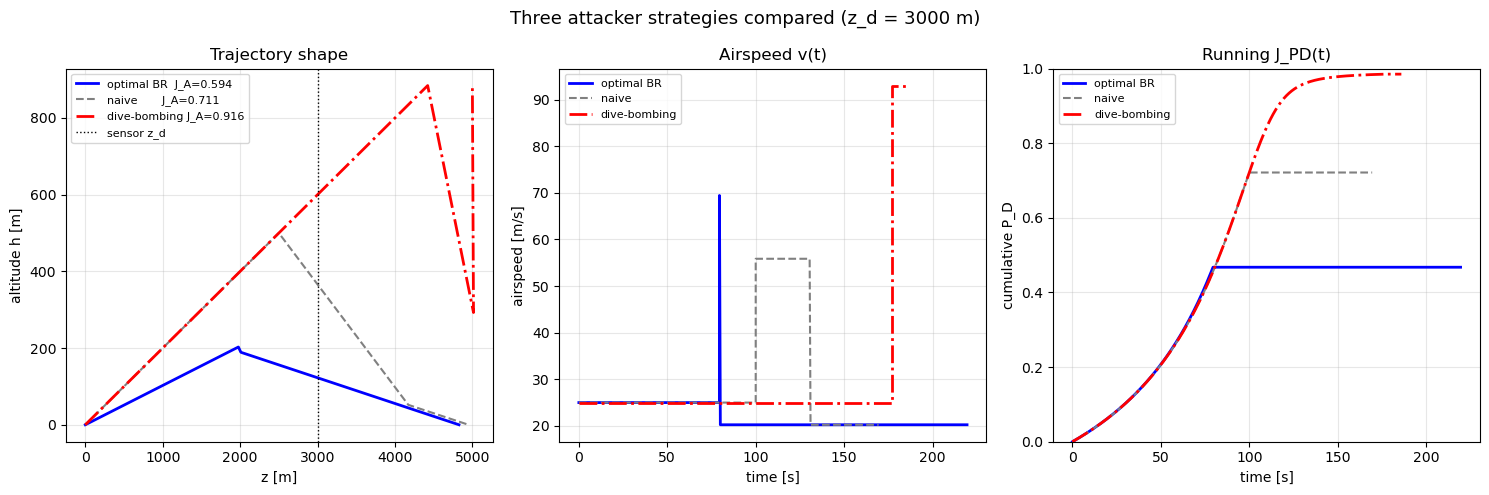

In [28]:
# ── Plot all three trajectories ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Three attacker strategies compared (z_d = 3000 m)", fontsize=13)

# Trajectory shape
axes[0].plot(arr_br["z"],    arr_br["h"],
             color="blue",   linewidth=2,
             label=f"optimal BR  J_A={br['J_A']:.3f}")
axes[0].plot(arr_naive["z"], arr_naive["h"],
             color="gray",   linewidth=1.5, linestyle="--",
             label=f"naive       J_A={naive['J_A']:.3f}")
axes[0].plot(arr_dive["z"],  arr_dive["h"],
             color="red",    linewidth=2, linestyle="-.",
             label=f"dive-bombing J_A={J_A_dive:.3f}")
axes[0].axvline(z_d_eval, color="black", linestyle=":",
                linewidth=1, label="sensor z_d")
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("altitude h [m]")
axes[0].set_title("Trajectory shape")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Airspeed
axes[1].plot(arr_br["t"],    arr_br["v"],
             color="blue",  linewidth=2,   label="optimal BR")
axes[1].plot(arr_naive["t"], arr_naive["v"],
             color="gray",  linewidth=1.5, linestyle="--", label="naive")
axes[1].plot(arr_dive["t"],  arr_dive["v"],
             color="red",   linewidth=2,   linestyle="-.", label="dive-bombing")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("airspeed [m/s]")
axes[1].set_title("Airspeed v(t)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Running J_PD
def running_jpd(arr, rates):
    dt     = np.diff(arr["t"])
    total  = sum(rates[k] for k in rates)
    cumint = np.concatenate([[0],
                              np.cumsum(0.5 * (total[:-1] + total[1:]) * dt)])
    return 1.0 - np.exp(-cumint)

jpd_br    = running_jpd(arr_br,    rates_br)
jpd_naive = running_jpd(arr_naive, rates_naive)
jpd_dive  = running_jpd(arr_dive,  rates_dive)

axes[2].plot(arr_br["t"],    jpd_br,
             color="blue",  linewidth=2,   label="optimal BR")
axes[2].plot(arr_naive["t"], jpd_naive,
             color="gray",  linewidth=1.5, linestyle="--", label="naive")
axes[2].plot(arr_dive["t"],  jpd_dive,
             color="red",   linewidth=2,   linestyle="-.", label="dive-bombing")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("cumulative P_D")
axes[2].set_title("Running J_PD(t)")
axes[2].set_ylim([0, 1])
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
switch_idx_naive = np.argmax(naive['arrays']['phase'] == 2)
switch_idx_dive  = np.argmax(arr_dive['phase'] == 2)
switch_idx_br    = np.argmax(arr_br['phase'] == 2)

print(f"Naive:        h_sw={naive['arrays']['h'][switch_idx_naive]:.1f} m, "
      f"gamma={np.degrees(naive['arrays']['gamma'][switch_idx_naive]):.1f} deg, "
      f"final h={naive['arrays']['h'][-1]:.1f} m, "
      f"final z={naive['arrays']['z'][-1]:.1f} m")

print(f"Dive-bombing: h_sw={arr_dive['h'][switch_idx_dive]:.1f} m, "
      f"gamma={np.degrees(arr_dive['gamma'][switch_idx_dive]):.1f} deg, "
      f"final h={arr_dive['h'][-1]:.1f} m, "
      f"final z={arr_dive['z'][-1]:.1f} m")

print(f"Optimal BR:   h_sw={arr_br['h'][switch_idx_br]:.1f} m, "
      f"gamma={np.degrees(arr_br['gamma'][switch_idx_br]):.1f} deg, "
      f"final h={arr_br['h'][-1]:.1f} m, "
      f"final z={arr_br['z'][-1]:.1f} m")

Naive:        h_sw=500.0 m, gamma=-15.0 deg, final h=0.0 m, final z=4949.8 m
Dive-bombing: h_sw=884.5 m, gamma=-45.0 deg, final h=884.5 m, final z=5000.0 m
Optimal BR:   h_sw=202.8 m, gamma=-23.3 deg, final h=0.0 m, final z=4827.0 m
